# Raisin Detective – XGBoost Model

In this notebook, we train and evaluate an XGBoost classifier for the Raisin dataset.

XGBoost is an ensemble method based on boosting. Unlike Random Forest, where many trees are trained more independently, XGBoost builds trees sequentially. Each new tree tries to correct the mistakes made by the previous trees.

The goal is to compare XGBoost with the Decision Tree and Random Forest models.

In [5]:
import sys
print(sys.executable)

c:\Users\mahta\anaconda3\python.exe


In [6]:
import sys
!{sys.executable} -m pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 4.1 MB/s eta 0:00:25
    --------------------------------------- 1.6/101.7 MB 4.6 MB/s eta 0:00:22
   - -------------------------------------- 4.2/101.7 MB 7.5 MB/s eta 0:00:14
   -- ------------------------------------- 6.8/101.7 MB 9.0 MB/s eta 0:00:11
   --- ------------------------------------ 9.7/101.7 MB 10.2 MB/s eta 0:00:10
   ---- ----------------------------------- 12.3/101.7 MB 10.7 MB/s eta 0:00:09
   ----- ---------------------------------- 14.9/101.7 MB 11.0 MB/s eta 0:00:08
   ------ --------------------------------- 17.6/101.7 MB 11.3 MB/s eta 0:00:08
   -------- ------------------------------- 20.4/101.7 MB 11.5 MB/s eta 0:00:08
   --------- ------------------------------ 23.1/101.7 MB 11.7 MB/s eta 0:00:07
   ---------- ----------------------------- 25.7/101.7 MB 11.8 MB/s eta 0:00:07
   ----------- ---------------------------- 28.3/101.7 MB 

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

In [8]:
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

In [9]:
PROJECT_ROOT = Path("../..")
DATA_RAW = PROJECT_ROOT / "data" / "raw"

csv_path = DATA_RAW / "raisin_dataset.csv"

df = pd.read_csv(csv_path)

df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [10]:
X = df.drop(columns="Class")
y = df["Class"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
class_mapping

{'Besni': np.int64(0), 'Kecimen': np.int64(1)}

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (720, 7)
X_test shape: (180, 7)
y_train shape: (720,)
y_test shape: (180,)


## Train/Test Split

We use the same train/test split as in the previous notebooks: 80% training data and 20% test data.

The split uses `random_state=42` and `stratify=y` to keep the class distribution balanced and make the model results comparable with Decision Tree and Random Forest.

In [13]:
xgb_baseline = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_baseline.fit(X_train, y_train)

y_pred_xgb = xgb_baseline.predict(X_test)

In [14]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost Baseline Accuracy: {xgb_accuracy:.4f}")

XGBoost Baseline Accuracy: 0.8556


In [15]:
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       Besni       0.93      0.77      0.84        90
     Kecimen       0.80      0.94      0.87        90

    accuracy                           0.86       180
   macro avg       0.87      0.86      0.85       180
weighted avg       0.87      0.86      0.85       180



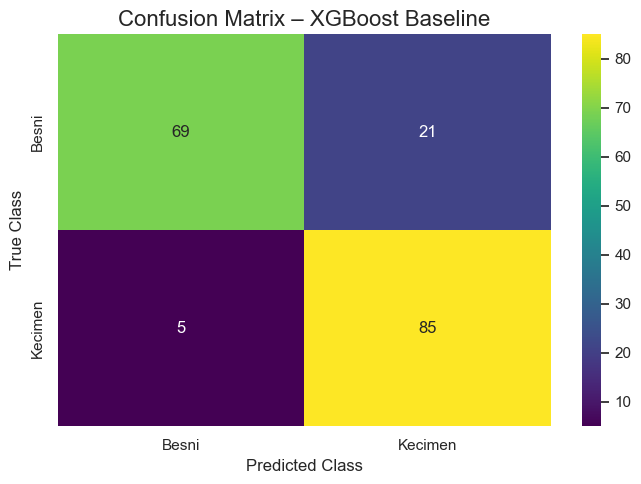

In [16]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix – XGBoost Baseline")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

## Baseline XGBoost Result

The baseline XGBoost model gives us an initial result before hyperparameter tuning.

This result can be compared with the Decision Tree and Random Forest models to see whether boosting improves classification performance.

In [17]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 5],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search_xgb.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [18]:
print("Best parameters:")
print(grid_search_xgb.best_params_)

print(f"Best cross-validation accuracy: {grid_search_xgb.best_score_:.4f}")

Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best cross-validation accuracy: 0.8722


In [19]:
best_xgb_model = grid_search_xgb.best_estimator_

y_pred_best_xgb = best_xgb_model.predict(X_test)

best_xgb_accuracy = accuracy_score(y_test, y_pred_best_xgb)

print(f"Tuned XGBoost Test Accuracy: {best_xgb_accuracy:.4f}")

Tuned XGBoost Test Accuracy: 0.8500


In [20]:
print(classification_report(
    y_test,
    y_pred_best_xgb,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       Besni       0.92      0.77      0.84        90
     Kecimen       0.80      0.93      0.86        90

    accuracy                           0.85       180
   macro avg       0.86      0.85      0.85       180
weighted avg       0.86      0.85      0.85       180



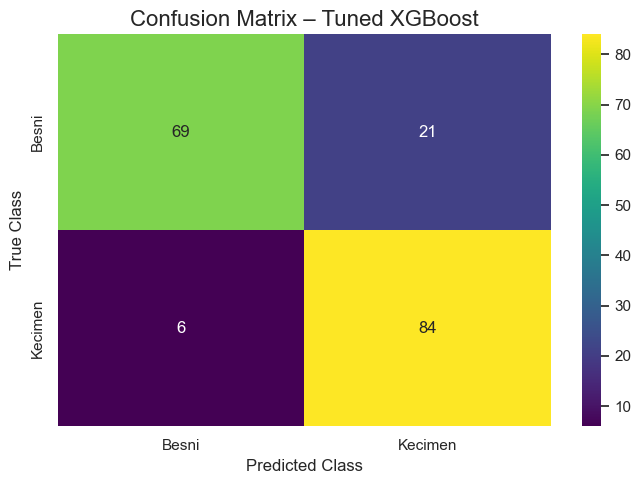

In [21]:
cm_best_xgb = confusion_matrix(y_test, y_pred_best_xgb)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_best_xgb,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix – Tuned XGBoost")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

In [22]:
model_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest Baseline",
        "Tuned Random Forest",
        "XGBoost Baseline",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        0.8444,
        0.8667,
        0.8722,
        xgb_accuracy,
        best_xgb_accuracy
    ]
})

model_results

,Model,Accuracy
0,Decision Tree,0.844400
1,Random Forest Baseline,0.866700
2,Tuned Random Forest,0.872200
3,XGBoost Baseline,0.855556
4,Tuned XGBoost,0.850000


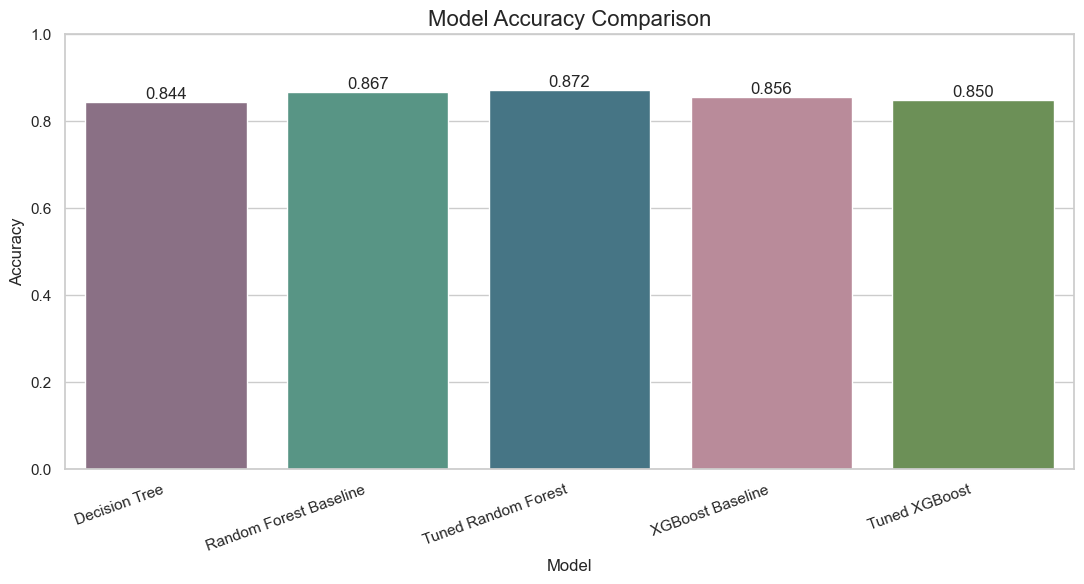

In [23]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=model_results,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette=["#8E6C88", "#4E9F8A", "#3B7A8F", "#C08497", "#6A994E"],
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## XGBoost Summary

XGBoost was tested as an additional ensemble model and compared with Decision Tree and Random Forest.

Because XGBoost builds trees sequentially and tries to correct previous mistakes, it can sometimes outperform Random Forest. However, the final result depends on the dataset and hyperparameter settings.

The comparison helps us decide which model performs best for classifying Kecimen and Besni raisins.

## XGBoost Result Interpretation

The XGBoost baseline model achieved an accuracy of approximately 85.6%, while the tuned XGBoost model achieved approximately 85.0%.

In this case, hyperparameter tuning did not improve the XGBoost model. This can happen when the baseline settings already work reasonably well, or when the selected parameter grid does not contain a better combination for this dataset.

Compared with the other models, the Tuned Random Forest achieved the best performance with approximately 87.2% accuracy. This suggests that Random Forest is the strongest model for this dataset among the models tested.

The result also shows that a more advanced model does not always guarantee better performance. Model performance depends on the dataset, feature relationships and hyperparameter settings.